# Investigating a synthetic supply chain

Four things are hidden in this dataset, and four perfectly innocent things look exactly like them. This notebook builds the network, gets a feel for how it ordinarily behaves, writes the detectors a procurement team would write, and scores every one of them against the ground truth, including the innocent suppliers they accuse.

The point is the last part. Any of these rules can be made to find its target; the question each one has to answer is what it costs to run, and that is only answerable on data where the innocent lookalikes are present and labelled.

| what is hidden | its legitimate twin | what both leave behind |
|---|---|---|
| `phantom_supplier` | `disruption_cascade` | invoices with no goods behind them |
| `invoice_kiting` | `consignment_loop` | value going round a circle of related suppliers |
| `split_orders` | `blanket_calloffs` | many purchases just under the approval limit |
| `counterfeit_injection` | `quality_incident` | a lane priced below what the part costs |

In [1]:
import warnings
import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(12)
pl.Config.set_fmt_str_lengths(28)

from graphfaker.domains.supply_chain import generate, evaluate, hardness_report, realism_report

run = generate(scale=0.01, hardness="medium", seed=42)
THRESHOLD = run.manifest.extra["supply_chain"]["approval_threshold"]

print("nodes:", {k: v.height for k, v in run.tables.nodes.items()})
print("edges:", {k: v.height for k, v in run.tables.edges.items()})
print(f"approval threshold: {THRESHOLD:,.0f}")

graphfaker:2026-10-05 10:10:34,954 - graphfaker - INFO - supply_chain: 500 suppliers, 5 plants, 20 warehouses, 5000 customers


graphfaker:2026-10-05 10:10:34,984 - graphfaker - INFO - supply_chain: 15 patterns (10 fraudulent, 5 legitimate), 208 events


graphfaker:2026-10-05 10:10:35,497 - graphfaker - INFO - supply_chain: 444428 legitimate events


nodes: {'Supplier': 500, 'Plant': 5, 'Warehouse': 20, 'Customer': 5000, 'Product': 200, 'Carrier': 10}
edges: {'SUPPLIES': 127, 'SUBCONTRACTS': 580, 'PRODUCES': 29, 'STOCKS': 222, 'SERVES': 5000, 'HAULS': 31, 'ORDERS': 139958, 'SHIPS': 107538, 'INVOICES': 107994, 'INTERCOMPANY': 29190, 'DELIVERS': 59956}
approval threshold: 25,000


## 1. The network

Suppliers sit in three tiers. Tier 1 holds the contracts with the plants; tiers 2 and 3 sell to the tier above, which is where visibility runs out in a real programme and where a substituted part is worth hiding.

In [2]:
suppliers = run.tables.nodes["Supplier"]
print(suppliers.group_by("tier").agg(
    pl.len().alias("suppliers"),
    pl.col("on_time_rate").mean().round(3).alias("mean_on_time"),
    pl.col("capacity_units").median().alias("median_capacity"),
).sort("tier"))

sub = run.tables.edges["SUBCONTRACTS"]
G = nx.from_edgelist(zip(sub["source"].to_list(), sub["target"].to_list()))
degrees = np.array([d for _, d in G.degree()])
print(f"\nsubcontracting graph: {G.number_of_nodes()} suppliers, {G.number_of_edges()} relationships")
print(f"partners per supplier: median {np.median(degrees):.0f}, 90th percentile {np.percentile(degrees, 90):.0f}, max {degrees.max()}")
print(f"suppliers sitting on at least one cycle: {sum(len(c) for c in nx.cycle_basis(G)) > 0}")

shape: (3, 4)
┌──────┬───────────┬──────────────┬─────────────────┐
│ tier ┆ suppliers ┆ mean_on_time ┆ median_capacity │
│ ---  ┆ ---       ┆ ---          ┆ ---             │
│ i64  ┆ u32       ┆ f64          ┆ f64             │
╞══════╪═══════════╪══════════════╪═════════════════╡
│ 1    ┆ 84        ┆ 0.863        ┆ 5709.5          │
│ 2    ┆ 153       ┆ 0.867        ┆ 4865.0          │
│ 3    ┆ 263       ┆ 0.87         ┆ 4470.0          │
└──────┴───────────┴──────────────┴─────────────────┘

subcontracting graph: 415 suppliers, 579 relationships
partners per supplier: median 2, 90th percentile 5, max 19
suppliers sitting on at least one cycle: True


The graph has cycles in it, and that matters for what comes later. Co-manufacturing between suppliers at the same level and sub-assemblies sold back up the chain mean goods legitimately travel in loops. Without them, any circle would be anomalous by construction and the kiting detector below would be a one-line query.

## 2. How the network ordinarily behaves

Nothing here is suspicious on its own. An invoice is a number, a late shipment is weather, a small order is a small order. What makes anything findable is how it sits against the ordinary rhythm, so it is worth looking at the rhythm first.

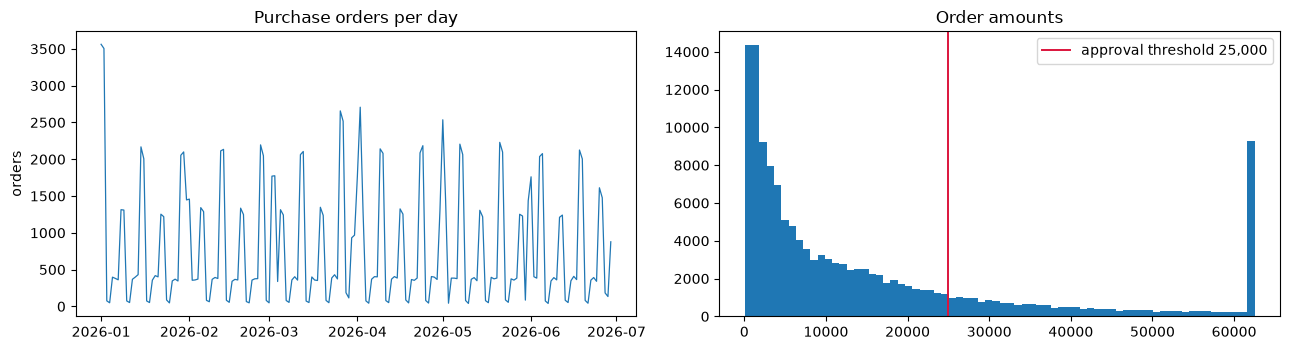

scheduled replenishment: 62.0% of orders
orders above the approval threshold: 20.9%
weekend orders: 6.6%


In [3]:
orders = run.tables.edges["ORDERS"]
per_day = (
    orders.with_columns(pl.col("timestamp").dt.date().alias("day"))
    .group_by("day").agg(pl.len().alias("orders"))
    .sort("day")
)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(per_day["day"].to_list(), per_day["orders"].to_list(), lw=0.9)
axes[0].set_title("Purchase orders per day")
axes[0].set_ylabel("orders")

amounts = orders["amount"].to_numpy()
axes[1].hist(np.clip(amounts, 0, THRESHOLD * 2.5), bins=70)
axes[1].axvline(THRESHOLD, color="crimson", lw=1.4, label=f"approval threshold {THRESHOLD:,.0f}")
axes[1].set_title("Order amounts")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"scheduled replenishment: {orders['scheduled'].mean():.1%} of orders")
print(f"orders above the approval threshold: {(amounts > THRESHOLD).mean():.1%}")
print(f"weekend orders: {orders['timestamp'].dt.weekday().is_in([6, 7]).mean():.1%}")

Three things to take from that. Replenishment is scheduled, so an order off-schedule means something. The calendar is visible: weekdays over weekends, and the last days of a quarter over everything, because budgets. And about one order in nine is over the approval threshold, which is what makes staying under it a decision rather than an accident.

In [4]:
print("realism report:")
for key, value in realism_report(run).items():
    print(f"  {key:<28}{value:>10.3f}")

realism report:
  scheduled_share                  0.620
  order_amount_p90             46312.730
  ship_to_order_ratio              0.768
  invoice_to_ship_ratio            1.004
  top1pct_customer_share           0.171
  suppliers_per_plant             25.400


## 3. What is actually in there

The ground truth is written next to the data. It is what makes this an experiment rather than a demonstration, and `--blind` leaves it out when you want to hand the dataset to someone who should not see it.

In [5]:
patterns = run.truth["patterns"]
print(patterns.group_by(["play", "is_fraud"]).agg(
    pl.len().alias("patterns"),
    pl.col("n_suppliers").sum().alias("suppliers"),
    pl.col("n_events").sum().alias("events"),
).sort(["is_fraud", "play"], descending=[True, False]))

guilty = set(run.truth["suppliers"].filter(pl.col("is_fraud"))["supplier_id"].to_list())
innocent = set(run.truth["suppliers"].filter(~pl.col("is_fraud"))["supplier_id"].to_list()) - guilty
active = set(run.tables.edges["INVOICES"]["source"].to_list()) | set(run.tables.edges["INTERCOMPANY"]["source"].to_list())
print(f"\n{len(guilty)} suppliers in a scheme, {len(innocent)} in a legitimate structure that looks like one")
print(f"{len(active)} suppliers traded at all, so the base rate among them is {len(guilty)/len(active):.1%}")

shape: (8, 5)
┌───────────────────────┬──────────┬──────────┬───────────┬────────┐
│ play                  ┆ is_fraud ┆ patterns ┆ suppliers ┆ events │
│ ---                   ┆ ---      ┆ ---      ┆ ---       ┆ ---    │
│ str                   ┆ bool     ┆ u32      ┆ i64       ┆ i64    │
╞═══════════════════════╪══════════╪══════════╪═══════════╪════════╡
│ counterfeit_injection ┆ true     ┆ 2        ┆ 4         ┆ 28     │
│ invoice_kiting        ┆ true     ┆ 2        ┆ 8         ┆ 13     │
│ phantom_supplier      ┆ true     ┆ 3        ┆ 3         ┆ 28     │
│ split_orders          ┆ true     ┆ 3        ┆ 3         ┆ 48     │
│ counterfeit_injection ┆ false    ┆ 1        ┆ 1         ┆ 10     │
│ invoice_kiting        ┆ false    ┆ 1        ┆ 3         ┆ 7      │
│ phantom_supplier      ┆ false    ┆ 2        ┆ 9         ┆ 50     │
│ split_orders          ┆ false    ┆ 1        ┆ 1         ┆ 24     │
└───────────────────────┴──────────┴──────────┴───────────┴────────┘

17 suppliers in a s

## 4. Four detectors

Each one is the first thing somebody would write for the play it targets. They are scored the same way: flag suppliers, hand the list to `evaluate`, and read precision, recall, and the share of innocent lookalikes caught.

In [6]:
def score(name, flagged):
    result = evaluate(run, flagged_suppliers=list(flagged))
    best = max(result.recall_by_play.items(), key=lambda kv: kv[1])
    return {
        "detector": name,
        "flagged": len(set(flagged)),
        "precision": round(result.supplier.precision, 3),
        "recall": round(result.supplier.recall, 3),
        "best_play": f"{best[0]} {best[1]:.0%}",
        "innocent_flagged": round(result.legitimate_false_positive_rate, 3),
    }

results = []

### Orders just under the limit

Count the orders in the band below the approval threshold. This is the rule every procurement team has.

In [7]:
near = run.tables.edges["ORDERS"].filter(
    (pl.col("amount") > THRESHOLD * 0.8) & (pl.col("amount") < THRESHOLD)
)
threshold_rule = near.group_by("target").len().filter(pl.col("len") >= 4)["target"].to_list()
results.append(score("orders under the limit", threshold_rule))
print(results[-1])

{'detector': 'orders under the limit', 'flagged': 48, 'precision': 0.104, 'recall': 0.294, 'best_play': 'split_orders 100%', 'innocent_flagged': 0.357}


### Invoices with no goods behind them

Every invoice carries a reference to the shipment it follows. Suppliers billing without shipping are the phantom signature, and also what a port closure looks like from the ledger.

In [8]:
shipped = set(run.tables.edges["SHIPS"]["event_id"].to_list())
unmatched = (
    run.tables.edges["INVOICES"]
    .with_columns(pl.col("reference").is_in(list(shipped)).alias("has_goods"))
    .group_by("source")
    .agg(pl.len().alias("invoices"), (~pl.col("has_goods")).sum().alias("without_goods"))
    .with_columns((pl.col("without_goods") / pl.col("invoices")).alias("share"))
)
phantom_rule = unmatched.filter((pl.col("share") > 0.3) & (pl.col("invoices") >= 3))["source"].to_list()
results.append(score("invoices without goods", phantom_rule))
print(results[-1])

{'detector': 'invoices without goods', 'flagged': 84, 'precision': 0.107, 'recall': 0.529, 'best_play': 'split_orders 100%', 'innocent_flagged': 0.857}


### A lane priced below what the part costs

A substituted part is cheaper than the real one, and the saving shows up as a unit price under the norm for that product. So does a rework credit after a quality incident, which is the whole difficulty.

In [9]:
ships = run.tables.edges["SHIPS"].with_columns(
    (pl.col("amount") / pl.col("quantity").cast(pl.Float64).clip(1.0)).alias("unit_price")
)
norm = ships["unit_price"].median()
cheap = (
    ships.group_by("source")
    .agg(pl.len().alias("shipments"), (pl.col("unit_price") / norm).mean().alias("price_ratio"))
    .filter((pl.col("price_ratio") < 0.75) & (pl.col("shipments") >= 3))
)
price_rule = cheap["source"].to_list()
results.append(score("lane priced under cost", price_rule))
print(results[-1])

{'detector': 'lane priced under cost', 'flagged': 27, 'precision': 0.037, 'recall': 0.059, 'best_play': 'counterfeit_injection 25%', 'innocent_flagged': 0.214}


### Value going round in a circle

Inter-company movements form a graph, and a kiting ring is a cycle in it. This is the detector everyone reaches for first, and it is worth watching it fail twice in opposite directions.

In [10]:
moves = run.tables.edges["INTERCOMPANY"]
directed = nx.DiGraph()
directed.add_edges_from(set(zip(moves["source"].to_list(), moves["target"].to_list())))
print(f"suppliers with any inter-company movement: {directed.number_of_nodes()}")
print(f"cycles up to 3 hops: {len(list(nx.simple_cycles(directed, length_bound=3)))}")
print(f"cycles up to 6 hops: {len(list(nx.simple_cycles(directed, length_bound=6)))}")

on_a_cycle = {node for cycle in nx.simple_cycles(directed, length_bound=6) for node in cycle}
results.append(score("on any cycle", on_a_cycle))
print(results[-1])

suppliers with any inter-company movement: 415

cycles up to 3 hops: 585


cycles up to 6 hops: 1084


{'detector': 'on any cycle', 'flagged': 415, 'precision': 0.041, 'recall': 1.0, 'best_play': 'split_orders 100%', 'innocent_flagged': 1.0}


Being on a cycle says nothing at all: it flags essentially every supplier that trades. Goods move both ways between related companies, so two suppliers with a relationship are already a cycle, and a few hundred of those make thousands of longer ones. In a real group this is exactly what you would find, which is why "look for circular trading" is not a control.

So tighten it the way an analyst would: a ring passes roughly the same value hop to hop, in a short window. Require the amounts around the circle to agree within 10% and the whole loop to close inside three weeks.

In [11]:
movements = {}
for source, target, amount, stamp in zip(
    moves["source"].to_list(), moves["target"].to_list(),
    moves["amount"].to_list(), moves["timestamp"].to_list(),
):
    movements.setdefault((source, target), []).append((amount, stamp))

def closed_loops(tolerance=1.10, days=21, min_hops=4):
    found = []
    for cycle in nx.simple_cycles(directed, length_bound=6):
        if len(cycle) < min_hops:
            continue
        hops = [(cycle[i], cycle[(i + 1) % len(cycle)]) for i in range(len(cycle))]
        options = [movements.get(hop, []) for hop in hops]
        if any(not option for option in options):
            continue
        for anchor, when in options[0]:
            if all(
                any(anchor / tolerance <= a <= anchor * tolerance and abs((t - when).days) <= days
                    for a, t in option)
                for option in options[1:]
            ):
                found.append(cycle)
                break
    return found

loops = closed_loops()
cycle_rule = {node for cycle in loops for node in cycle}
print(f"cycles that pass the same value round in three weeks: {len(loops)}")
results.append(score("value-conserving cycle", cycle_rule))
print(results[-1])

cycles that pass the same value round in three weeks: 32
{'detector': 'value-conserving cycle', 'flagged': 62, 'precision': 0.0, 'recall': 0.0, 'best_play': 'counterfeit_injection 0%', 'innocent_flagged': 0.286}


And now it finds no rings at all. Not a few: none.

That is the dataset working as intended rather than a bug. At `medium` hardness, `amount_blend` draws half the ring's movements from the ordinary distribution for that product, so the value does not travel round the loop unchanged, and `timing_spread_days` stretches the circle over weeks. The signature the query is written for has been taken away, and what is left is a circle that looks like all the other circles.

The hardness report at the end of this notebook puts a number on it: `invoice_kiting` is the hardest of the four plays, and no single feature separates its members from ordinary trading suppliers at better than about 0.68 AUC.

## 5. All of it, side by side

In [12]:
print(pl.DataFrame(results))

# Everything except the degenerate one: flagging every supplier that trades
# is not a detector, it is a list of suppliers.
combined = set(threshold_rule) | set(phantom_rule) | set(price_rule) | set(cycle_rule)
results.append(score("all four together", combined))
print("\n", pl.DataFrame([results[-1]]))

shape: (5, 6)
┌───────────────────┬─────────┬───────────┬────────┬────────────────────────────┬──────────────────┐
│ detector          ┆ flagged ┆ precision ┆ recall ┆ best_play                  ┆ innocent_flagged │
│ ---               ┆ ---     ┆ ---       ┆ ---    ┆ ---                        ┆ ---              │
│ str               ┆ i64     ┆ f64       ┆ f64    ┆ str                        ┆ f64              │
╞═══════════════════╪═════════╪═══════════╪════════╪════════════════════════════╪══════════════════╡
│ orders under the  ┆ 48      ┆ 0.104     ┆ 0.294  ┆ split_orders 100%          ┆ 0.357            │
│ limit             ┆         ┆           ┆        ┆                            ┆                  │
│ invoices without  ┆ 84      ┆ 0.107     ┆ 0.529  ┆ split_orders 100%          ┆ 0.857            │
│ goods             ┆         ┆           ┆        ┆                            ┆                  │
│ lane priced under ┆ 27      ┆ 0.037     ┆ 0.059  ┆ counterfeit_injection 25

Read the last two columns together, because neither means much alone.

Each rule finds the play it was written for and close to nothing else. The threshold rule gets every split-order scheme, the unmatched-invoice rule gets every phantom supplier, the price rule gets a quarter of the substitutions, and the two cycle rules find no rings at all. Running them together is better than any one alone, which is the honest argument for combining evidence rather than tuning a single signal, and it is still a long way from solving the problem.

The last column is why the twins exist. Every rule accuses innocent suppliers, because the innocent structures leave the same trace: the unmatched-invoice rule flags 86% of them, which is the port closure doing exactly what a phantom supplier does to a ledger. That is the cost of running these controls, and on a dataset without the twins none of it would be visible: the same rules would report the same recall with a precision that quietly ignored the week the procurement team spends on blameless suppliers.

## 6. Which plays nobody found

In [13]:
full = evaluate(run, flagged_suppliers=list(combined))
print("recall by play, all four detectors together:")
for play, value in sorted(full.recall_by_play.items(), key=lambda kv: -kv[1]):
    print(f"  {play:<26}{value:>7.0%}")
print(f"\nsuppliers flagged: {len(combined)}, of which innocent lookalikes: "
      f"{len(combined & innocent)} of {len(innocent)}")
print(f"suppliers in a scheme and missed entirely: {len(guilty - combined)} of {len(guilty)}")
print(f"\npattern level: {full.pattern.tp} schemes reconstructed, {full.pattern.fn} missed, "
      f"{full.pattern.fp} legitimate structures accused")

recall by play, all four detectors together:
  phantom_supplier             100%
  split_orders                 100%
  counterfeit_injection         50%
  invoice_kiting                14%

suppliers flagged: 128, of which innocent lookalikes: 12 of 14
suppliers in a scheme and missed entirely: 8 of 17

pattern level: 8 schemes reconstructed, 2 missed, 4 legitimate structures accused


## 7. What the hardness dial is doing

`hardness` is an input to a measurement, not an adjective. The report scores every feature a first pass would use by the AUC it achieves separating a play's suppliers from the suppliers that trade and are in nothing.

In [14]:
print(hardness_report(run).summary())

hardness: medium
play                    kind              n   max AUC  best feature (family)
split_orders            fraud             3     0.985  order_count (volume)
counterfeit_injection   legitimate        1     0.971  order_count (volume)
split_orders            legitimate        1     0.969  under_threshold_share (threshold)
phantom_supplier        legitimate        9     0.958  distinct_plants (structure)
phantom_supplier        fraud             3     0.950  mean_amount (money)
counterfeit_injection   fraud             4     0.820  event_count (profile)
invoice_kiting          legitimate        3     0.753  onboarded_days (identity)
invoice_kiting          fraud             7     0.618  tier (identity)

decoy separability from its twin (lower is better):
  blanket_calloffs       vs split_orders            1.000  by unit_price_ratio
  consignment_loop       vs invoice_kiting          0.714  by invoice_without_shipment
  disruption_cascade     vs phantom_supplier        1.000  

In [15]:
rows = []
for level in ("low", "medium", "high"):
    other = generate(scale=0.01, hardness=level, seed=42)
    report = hardness_report(other)
    for play in report.plays:
        if play.is_fraud:
            rows.append({"hardness": level, "play": play.play, "max_auc": round(play.max_auc, 3),
                         "best_feature": play.best_feature})
print(pl.DataFrame(rows).pivot(values="max_auc", index="play", on="hardness"))

graphfaker:2026-10-05 10:10:41,686 - graphfaker - INFO - supply_chain: 500 suppliers, 5 plants, 20 warehouses, 5000 customers


graphfaker:2026-10-05 10:10:41,707 - graphfaker - INFO - supply_chain: 10 patterns (10 fraudulent, 0 legitimate), 160 events


graphfaker:2026-10-05 10:10:42,223 - graphfaker - INFO - supply_chain: 454250 legitimate events


graphfaker:2026-10-05 10:10:42,501 - graphfaker - INFO - supply_chain: 500 suppliers, 5 plants, 20 warehouses, 5000 customers


graphfaker:2026-10-05 10:10:42,530 - graphfaker - INFO - supply_chain: 15 patterns (10 fraudulent, 5 legitimate), 208 events


graphfaker:2026-10-05 10:10:43,064 - graphfaker - INFO - supply_chain: 444428 legitimate events


graphfaker:2026-10-05 10:10:43,438 - graphfaker - INFO - supply_chain: 500 suppliers, 5 plants, 20 warehouses, 5000 customers


graphfaker:2026-10-05 10:10:43,473 - graphfaker - INFO - supply_chain: 20 patterns (10 fraudulent, 10 legitimate), 195 events


graphfaker:2026-10-05 10:10:43,976 - graphfaker - INFO - supply_chain: 431980 legitimate events


shape: (4, 4)
┌───────────────────────┬───────┬────────┬───────┐
│ play                  ┆ low   ┆ medium ┆ high  │
│ ---                   ┆ ---   ┆ ---    ┆ ---   │
│ str                   ┆ f64   ┆ f64    ┆ f64   │
╞═══════════════════════╪═══════╪════════╪═══════╡
│ phantom_supplier      ┆ 1.0   ┆ 0.95   ┆ 0.999 │
│ invoice_kiting        ┆ 0.738 ┆ 0.618  ┆ 0.629 │
│ split_orders          ┆ 0.966 ┆ 0.985  ┆ 0.946 │
│ counterfeit_injection ┆ 0.799 ┆ 0.82   ┆ 0.893 │
└───────────────────────┴───────┴────────┴───────┘


At `low` the amounts are round, the shell supplier was onboarded last week, the orders sit at 99% of the limit, and the ring's movements are added on top of its members' ordinary trading so their volume stands out. At `high` the amounts come from the legitimate distribution for that supplier's own product, and the ordinary trading is displaced while the scheme runs so the totals say nothing. What is left is the shape, which is what the detectors above have to work with.

`docs/domains/supply-chain.md` has the five-seed version of this table and the one play that stays flat across the dial, with the reason.

## Where to take it

- `graphfaker load duckdb ./chain` puts this in a database and verifies the load against the files it came from; the
patterns land as `Pattern` nodes and `IN_PATTERN` relationships, so the truth is queryable alongside the data.
- `--sink pyg` exports a `HeteroData` with `y`, `decoy` and stratified splits on Supplier, for the obvious next
experiment: can a model beat these four rules, and does it accuse more innocent suppliers when it does.
- `--blind` writes the same dataset without the truth, which is the copy to hand to whoever is building the detector.